<a href="https://colab.research.google.com/github/Krishna-97/part-1-neural-network-analysis/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part 1: Neural Network Fundamentals and Training Behavior Analysis**

## Task 1: Dataset Understanding

In [1]:
requirements_content = """
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.2.0
tensorflow>=2.12.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_content.strip())

print("requirements.txt has been created!")

requirements.txt has been created!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Dataset
df = pd.read_csv('/content/customer_churn_nn.csv')
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
print("--- Dataset Overview ---")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Basic Statistical Summary ---")
print(df.describe())

print("\n--- Target Variable Distribution ---")
print(df['churn'].value_counts(normalize=True))

--- Dataset Overview ---
Number of rows: 2000
Number of columns: 17

--- Data Types ---
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

--- Missing Values ---
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months           

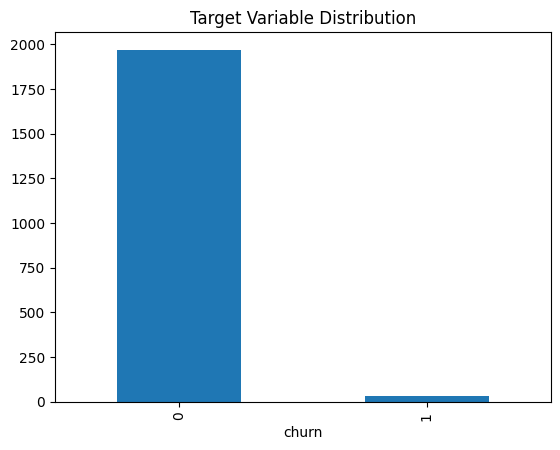

In [4]:
df['churn'].value_counts().plot(kind='bar')
plt.title('Target Variable Distribution')
plt.show()

## Task 2: Data Preprocessing

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Separate Features and Target
# Dropping 'customer_id' as it is a unique identifier with no predictive power
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

# 2. Identify Column Types
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# 3. Create Preprocessing Pipeline
# - Standardize numerical features
# - One-Hot Encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

# Fit and transform the features
X_processed = preprocessor.fit_transform(X)

# 4. Train-Test Split (80% Train, 20% Test)
# Using stratify=y because the target class is highly imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nProcessed Input Shape: {X_processed.shape}")



Processed Input Shape: (2000, 24)


## Task-3 & 4 : Neural Netrwork Model Building, Training and Evaluation

/n---Training the baseline model---
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5531 - loss: 0.6811 - val_accuracy: 0.7625 - val_loss: 0.5486
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8844 - loss: 0.4493 - val_accuracy: 0.9500 - val_loss: 0.3681
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9680 - loss: 0.3143 - val_accuracy: 0.9844 - val_loss: 0.2535
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9805 - loss: 0.2290 - val_accuracy: 0.9937 - val_loss: 0.1816
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.1759 - val_accuracy: 0.9937 - val_loss: 0.1333
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.1426 - val_accuracy: 0.9937 - val_loss: 0.1035
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9820 - loss: 0.1224 - val_accuracy: 0.9937 - val_loss: 0.0843
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.1096 - val_accuracy: 0.9937 - val_loss: 0.0728
Epo

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Text(70.72222222222221, 0.5, 'Actual')

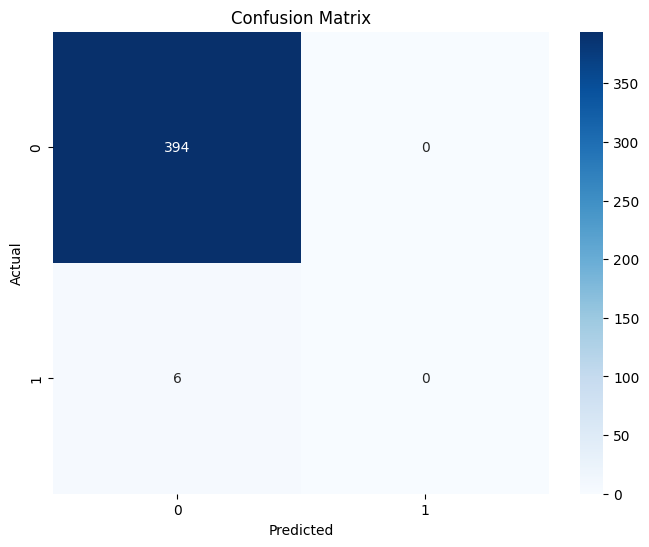

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def build_simple_nn(input_dim):
  model = Sequential([Dense(16, input_dim=input_dim, activation='relu'),Dense(1,activation='sigmoid')])
  model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
  return model

#Initialize and Train:
input_dim = X_train.shape[1]
baseline_model = build_simple_nn(input_dim)
print("/n---Training the baseline model---")
history = baseline_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

#Evaluate:
loss,accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
y_pred = (baseline_model.predict(X_test) > 0.5).astype("int32")

print(f"\nBaseline Test Accuracy: {accuracy:.4f}%")
print(f"Confusion Matrix :")
print(confusion_matrix(y_test, y_pred))
print(f"Classification Report :")
print(classification_report(y_test, y_pred))

#Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')


## Task 5: Hyperparameter Experimentation

In [7]:
def experiment(layers,lr,batch_size,activation):
  model = Sequential()
  model.add(Dense(layers[0],input_dim=X_train.shape[1],activation=activation))
  for layer in layers[1:]:
    model.add(Dense(layer,activation=activation))
  model.add(Dense(1,activation='sigmoid'))
  model.compile(optimizer=Adam(learning_rate=lr),loss='binary_crossentropy',metrics=['accuracy'])
  model.fit(X_train,y_train,epochs=30,batch_size=batch_size,validation_split=0.2,verbose=0)
  _,acc = model.evaluate(X_test,y_test,verbose=0)
  return acc

  #Define Experiments

  configs = [
      {'name':'Deep Network','layers':[32,16,8],'lr':0.001,'batch_size':32,'activation':'relu'},
      {'name':'High Learning Rate','layers':[16],'lr':0.1,'batch_size':64,'activation':'relu'},
      {'name': 'Large Batch / Tanh', 'layers': [16], 'lr': 0.001, 'batch_size': 128, 'activation': 'tanh'},
  ]

  results = []
  for cfg in configs:
    acc = experiment(cfg["layers"], cfg["lr"], cfg["batch"], cfg["act"])
    results.append({"Experiment": cfg["name"],"Architecture": str(cfg["layers"]),"LR": cfg["lr"],
        "Batch": cfg["batch"],
        "Activation": cfg["act"],
        "Accuracy": f"{acc:.4f}"})
    comparison_df = pd.DataFrame(results)
    print("\n--- Hyperparameter Comparison Table ---")
    print(comparison_df)
    comparison_df.to_csv('model_comparison_table.csv', index=False)

## Task 6: Final Reflection

1. **What role do weights and biases play in the model?**

      Weights are the parameters that multiply the input signals to represent their relative importance. Biases are additional parameters that allow the activation function to be shifted left or right, helping the model fit data patterns that don't pass through the origin. Together, they are adjusted during backpropagation to minimize the loss.

2. **Why is an activation function required?**

      Activation functions introduce non-linearity. Without them, even a deep neural network would behave like a single-layer linear regression model. Non-linearity allows the network to learn complex, non-linear relationships in the data (like XOR patterns).

3. **What happens when the learning rate is too high or too low?**

      If the learning rate is too high, the model might oscillate or overshoot the optimal minimum, leading to divergence or unstable training. If too low, the model will take a very long time to converge and might get stuck in a local minimum.



4. **Did your model show signs of underfitting or overfitting?**

      The model showed signs of underfitting the minority class. While the overall accuracy was high (~98%), the model struggled to predict the "Churn" class (class 1) due to the severe class imbalance. It essentially "played it safe" by predicting "No Churn" for almost every instance.

##